# LSQ Template Fitting for ab-type stars
##### PEER REVIEW NOTE: Full dataset is still private, use the post-quality cut csv

#### Skip to next section with post-quality cut csv

In [65]:
import pandas as pd

filename = "lc_cat.dat"

headers = ['objnum', 'ra', 'dec', 'objtype', 'glat', 'glong', 'dist', 'blendalert',
    'period', 'amplitude', 'mjd0', 'voff', 'avmagq', 'itempl', 'nfit',
    'chi2', 'vcalib', 'vext', 'absmag', 'a0four', 'a1four', 'a2four',
    'a3four', 'a4four', 'a5four', 'a6four', 'phi21four', 'phi31four',
    'phi41four', 'phi51four', 'phi61four', 'fourlcfix', 'dmaxfour', 'p_phi', 'fehlbob', 'fehcbob']

star_ids = []
ra_list = []
period_list=[]
dec_list = []
dist_list = []
time_list = []
flux_list = []
flux_err_list = []

with open(filename, 'r') as f:
    star_counter = 0
    while True:
        line = f.readline()
        if not line:
            break
            
        meta_values = line.strip().split()
        if len(meta_values) != len(headers):
            print(f"Warning: unexpected metadata length at star {star_counter}")
            continue

        meta_dict = dict(zip(headers, meta_values))
        ra = float(meta_dict['ra'])
        dec = float(meta_dict['dec'])
        dist = float(meta_dict['dist'])
        period = float(meta_dict['period'])
        star_counter += 1
        star_id = star_counter

        npoints_line = f.readline()
        if not npoints_line:
            break
        npoints = int(npoints_line.strip())

        for _ in range(npoints):
            lc_line = f.readline()
            if not lc_line:
                break
            t, flux, ferr = map(float, lc_line.strip().split())
            star_ids.append(star_id)
            ra_list.append(ra)
            dec_list.append(dec)
            dist_list.append(dist)
            time_list.append(t)
            period_list.append(period)
            flux_list.append(flux)
            flux_err_list.append(ferr)

lc_df1 = pd.DataFrame({
    'star_id': star_ids,
    'ra': ra_list,
    'dec': dec_list,
    'dist': dist_list,
    'period': period_list,
    'time': time_list,
    'flux': flux_list,
    'flux_err': flux_err_list
})

print(lc_df1.head())

   star_id       ra      dec          dist    period          time       flux  \
0        1  0.01303 -2.43007  22003.474609  0.493024  55406.391382  16.985323   
1        1  0.01303 -2.43007  22003.474609  0.493024  55406.392782  16.918287   
2        1  0.01303 -2.43007  22003.474609  0.493024  55409.423397  16.986592   
3        1  0.01303 -2.43007  22003.474609  0.493024  55409.424786  16.990150   
4        1  0.01303 -2.43007  22003.474609  0.493024  55426.316622  16.360303   

   flux_err  
0  0.033540  
1  0.030068  
2  0.069537  
3  0.040353  
4  0.033540  


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

counts = lc_df1.groupby("star_id")["time"].count()
med_err = lc_df1.groupby("star_id")["flux_err"].median()
amplitude = lc_df1.groupby("star_id")["flux"].apply(lambda x: np.max(x) - np.min(x))
periods = lc_df1.groupby("star_id")["period"].first()

qc = pd.DataFrame({
    "n_points": counts,
    "median_err": med_err,
    "amplitude": amplitude,
    "period": periods})

good_ids = qc[
    (qc["n_points"] > 100) &
    (qc["median_err"] < 0.033) &
    (qc["amplitude"] > 0.4) & (qc["amplitude"] < 1.5) &
    (qc["period"].between(0.44, 0.89))].index

lc_df_good = lc_df1[lc_df1["star_id"].isin(good_ids)].reset_index(drop=True)

print(f"Kept {len(good_ids)} stars with:")
print(">50 points, median err <0.05, amplitude >0.2, 0.44 ≤ P ≤ 0.89 d")
print(f"Total light-curve rows: {len(lc_df_good)}")
lc_df_good.to_csv("filtered_lightcurves_ab.csv", index=False)

Kept 418 stars with:
>50 points, median err <0.05, amplitude >0.2, 0.44 ≤ P ≤ 0.89 d
Total light-curve rows: 96719


In [24]:
qc_good = qc.loc[good_ids]
qc_good.to_csv("bailey_data.csv", index=True)

# Filtering Lightcurves, Initial Mean Template

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
lc_df_good = pd.read_csv("filtered_lightcurves_ab.csv")

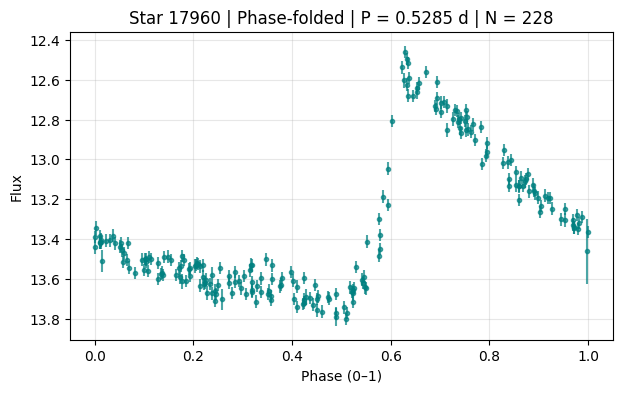

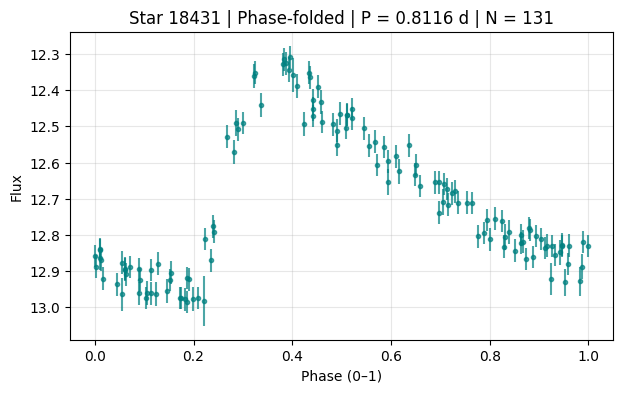

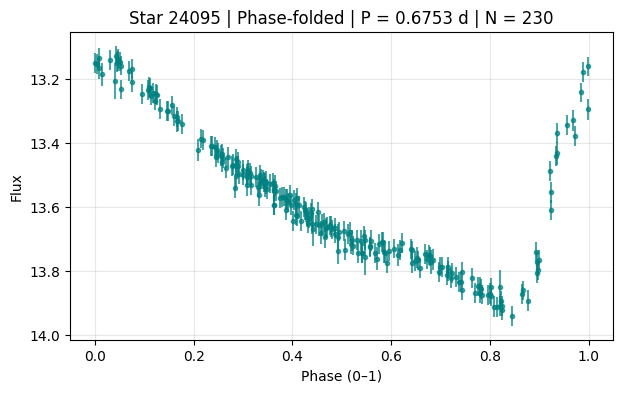

In [7]:
def fold_phase(time, period, t0=None):
    if t0 is None:
        t0 = np.min(time)
    return ((time - t0) / period) % 1.0

np.random.seed(42)
sample_ids = np.random.choice(lc_df_good["star_id"].unique(), size=3, replace=False)

for sid in sample_ids:
    g = lc_df_good[lc_df_good["star_id"] == sid]
    period = g["period"].iloc[0]
    phase = fold_phase(g["time"].values, period)

    plt.figure(figsize=(7, 4))
    plt.errorbar(phase, g["flux"], yerr=g["flux_err"], fmt=".", color="teal", alpha=0.7)
    plt.title(f"Star {sid} | Phase-folded | P = {period:.4f} d | N = {len(g)}")
    plt.xlabel("Phase (0–1)")
    plt.ylabel("Flux" if g["flux"].mean() < 100 else "Magnitude")
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3)
    plt.show()


In [9]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

def fold_phase_align(time, flux, period, align="min"):
    phase = ((time - np.min(time)) / period) % 1.0
    if align == "min":
        align_phase = phase[np.argmax(flux)]
    elif align == "max":
        align_phase = phase[np.argmin(flux)]
    else:
        align_phase = 0.0
    return (phase - align_phase) % 1.0


def normalize_mag(mag):
    mean = np.mean(mag)
    amp = np.max(mag) - np.min(mag)
    return (mag - mean) / amp

In [11]:
phase_grid = np.linspace(0, 1, 200)
templates = []

for sid, g in lc_df_good.groupby("star_id"):
    period = g["period"].iloc[0]
    phase = fold_phase_align(g["time"].values, g["flux"].values, period, align="max")
    mag_norm = normalize_mag(g["flux"].values)

    s = np.argsort(phase)
    f_interp = interp1d(phase[s], mag_norm[s], kind="cubic", fill_value="extrapolate")

    templates.append(f_interp(phase_grid))

templates = np.vstack(templates)
print(f"Interpolated {templates.shape[0]} light curves on a {len(phase_grid)}-point grid.")


Interpolated 418 light curves on a 200-point grid.


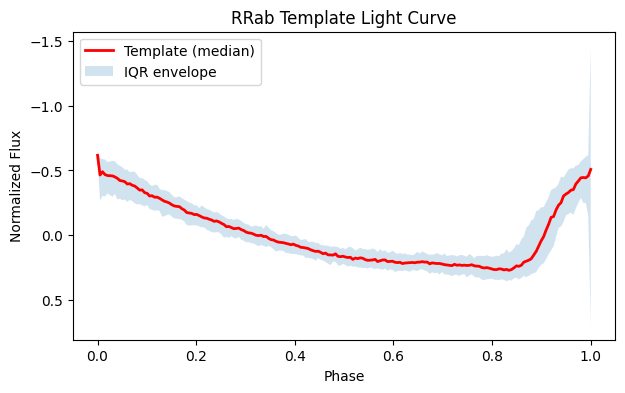

In [13]:
template_mean = np.median(templates, axis=0)

plt.figure(figsize=(7,4))
plt.plot(phase_grid, template_mean, 'r-', lw=2, label='Template (median)')
plt.fill_between(phase_grid, np.percentile(templates, 25, axis=0), np.percentile(templates, 75, axis=0), alpha=0.2, label='IQR envelope')
plt.gca().invert_yaxis()
plt.xlabel("Phase")
plt.ylabel("Normalized Flux")
plt.title("RRab Template Light Curve")
plt.legend()
plt.show()

### RSS, WLS, and Newton period update

In [16]:
from scipy.optimize import minimize
from scipy.interpolate import interp1d
import numpy as np

def fit_template_single(time, flux, flux_err, period, template_phase, template_flux):
    phase = ((time - np.min(time)) / period) % 1.0
    align_phase = phase[np.argmin(flux)]
    phase = (phase - align_phase) % 1.0
    
    T = interp1d(template_phase, template_flux, kind="cubic", fill_value="extrapolate")(phase)
    
    w = 1.0 / np.maximum(flux_err, 1e-6) ** 2

    def rss(params):
        A, m0 = params
        return np.sum(w * (flux - (m0 + A * T)) ** 2)

    res = minimize(rss, x0=[1.0, 0.0])
    A_fit, m0_fit = res.x
    rss_val = rss(res.x)
    return A_fit, m0_fit, rss_val

#### Steps: Folding the observed data (time, flux) onto a given trial period, aligning the phase by minimum flux, interpolating the template light curve onto those phases, and then computing a weighted residual sum of squares (RSS) between the observed flux and a scaled version of the template.

In [19]:
def template_rss_for_period(time, flux, flux_err, period, template_phase, template_flux):
    phase = ((time - np.min(time)) / period) % 1.0
    align_phase = phase[np.argmin(flux)]
    phase = (phase - align_phase) % 1.0
    T = interp1d(template_phase, template_flux, kind="cubic", fill_value="extrapolate")(phase)
    w = 1.0 / np.maximum(flux_err, 1e-6)**2
    A, m0 = np.polyfit(T, flux, 1, w=w)
    return np.sum(w * (flux - (m0 + A * T))**2)

#### Perturb the trial period slightly up and down, evaluate the RSS at those nearby periods and use a numerical gradient and Hessian to perform a one-step Newton update. Define a small perturbation in the period, then find period at updated high and low, first and second derivative WRT period.

In [22]:
def refine_period(time, flux, flux_err, period, template_phase, template_flux): 
    dP = 1e-4 * period
    rss0 = template_rss_for_period(time, flux, flux_err, period, template_phase, template_flux)
    rss1 = template_rss_for_period(time, flux, flux_err, period + dP, template_phase, template_flux)
    rss2 = template_rss_for_period(time, flux, flux_err, period - dP, template_phase, template_flux)
    grad = (rss1 - rss2) / (2 * dP)
    hess = (rss1 - 2 * rss0 + rss2) / (dP**2)
    period_new = period - grad / hess # Newton–Raphson step, finding where a function (derivative of RSS) equals zero
    return period_new

#### Fit the template light curve to the data using the refined period

In [25]:
results = []

for sid, g in lc_df_good.groupby("star_id"):
    t = g["time"].values
    f = g["flux"].values
    fe = g["flux_err"].values
    p = g["period"].iloc[0]

    p_refined = refine_period(t, f, fe, p, phase_grid, template_mean)
    
    A_fit, m0_fit, rss_val = fit_template_single(t, f, fe, p_refined, phase_grid, template_mean)

    results.append({
        "star_id": sid,
        "period_init": p,
        "period_refined": p_refined,
        "A_fit": A_fit,
        "m0_fit": m0_fit,
        "rss": rss_val})

fits_df = pd.DataFrame(results)
print(fits_df.head())


   star_id  period_init  period_refined     A_fit     m0_fit          rss
0      138     0.604887        0.604888  1.376464  13.764068   835.006509
1      218     0.548992        0.548985  0.825931  15.188861  3966.965719
2      229     0.634824        0.634806  0.611692  17.180565  2630.477985
3      260     0.549278        0.549276  1.208665  17.053674   703.568656
4      372     0.508759        0.508759  0.888330  15.885552  2014.391545


#### Plotting template model for particular star. Global template also scaled to same amplitude/offset for comparison

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

sid_example = fits_df.iloc[0]["star_id"]
g = lc_df_good[lc_df_good["star_id"] == sid_example].copy()

p_ref = fits_df.loc[fits_df["star_id"] == sid_example, "period_refined"].values[0]
A_fit = fits_df.loc[fits_df["star_id"] == sid_example, "A_fit"].values[0]
m0_fit = fits_df.loc[fits_df["star_id"] == sid_example, "m0_fit"].values[0]

phase = ((g["time"] - g["time"].min()) / p_ref) % 1.0
align_phase = phase[np.argmin(g["flux"])]
phase = (phase - align_phase) % 1.0
s = np.argsort(phase)
phase = phase[s]; flux = g["flux"].values[s]; err = g["flux_err"].values[s]

T_interp = interp1d(phase_grid, template_mean, kind="cubic", fill_value="extrapolate")
template_scaled = m0_fit + A_fit * T_interp(phase_grid)
flux_fit = m0_fit + A_fit * T_interp(phase)
residuals = flux - flux_fit

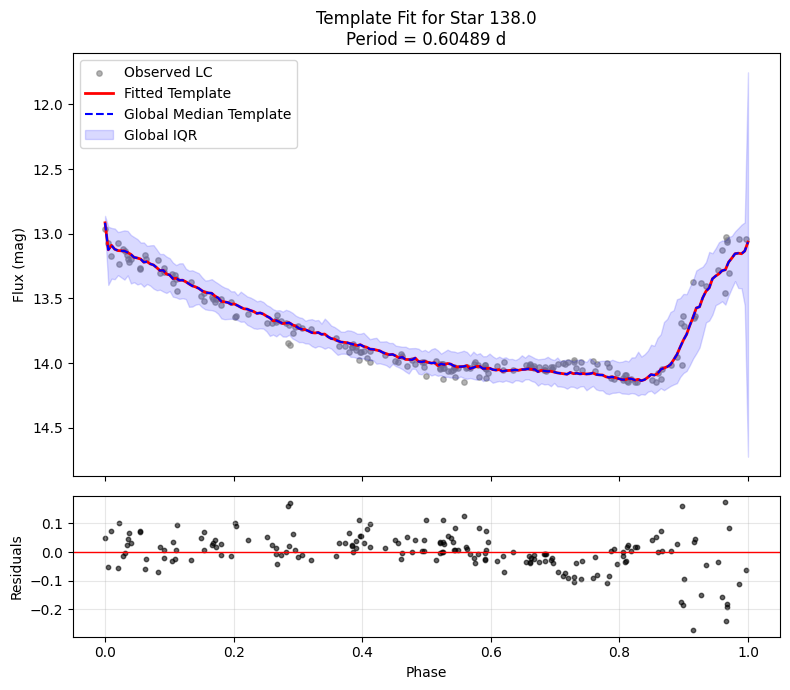

In [28]:
global_median_scaled = m0_fit + A_fit * np.median(templates, axis=0)
t25 = m0_fit + A_fit * np.percentile(templates, 25, axis=0)
t75 = m0_fit + A_fit * np.percentile(templates, 75, axis=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,7), sharex=True,
                               gridspec_kw={'height_ratios':[3,1]})

ax1.scatter(phase, flux, s=15, color='gray', alpha=0.6, label='Observed LC')
ax1.plot(phase_grid, template_scaled, 'r-', lw=2, label='Fitted Template')
ax1.plot(phase_grid, global_median_scaled, 'b--', lw=1.5, label='Global Median Template')
ax1.fill_between(phase_grid, t25, t75, color='blue', alpha=0.15, label='Global IQR')
ax1.invert_yaxis()
ax1.set_ylabel("Flux (mag)")
ax1.set_title(f"Template Fit for Star {sid_example}\nPeriod = {p_ref:.5f} d")
ax1.legend()

ax2.scatter(phase, residuals, s=10, color='black', alpha=0.6)
ax2.axhline(0, color='red', lw=1)
ax2.set_xlabel("Phase")
ax2.set_ylabel("Residuals")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


#### Random Star Test

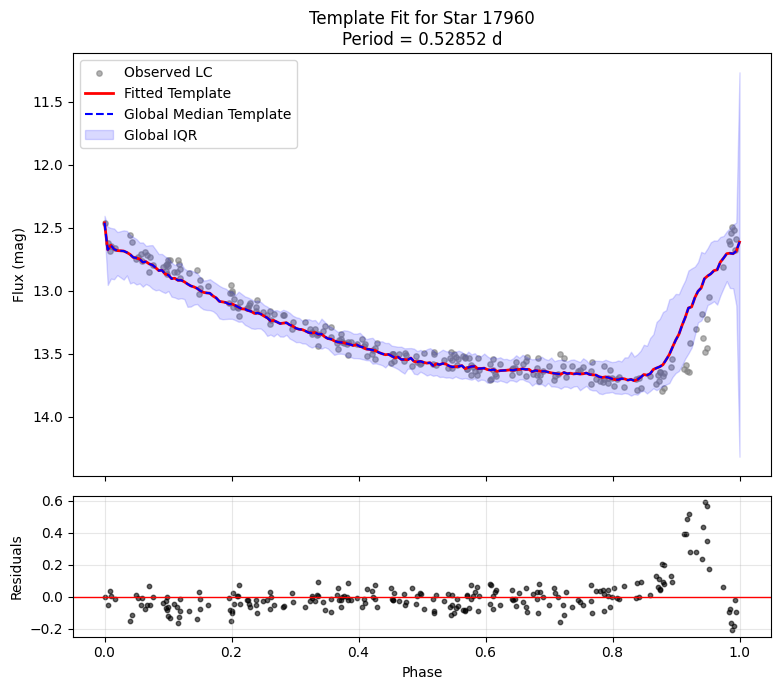

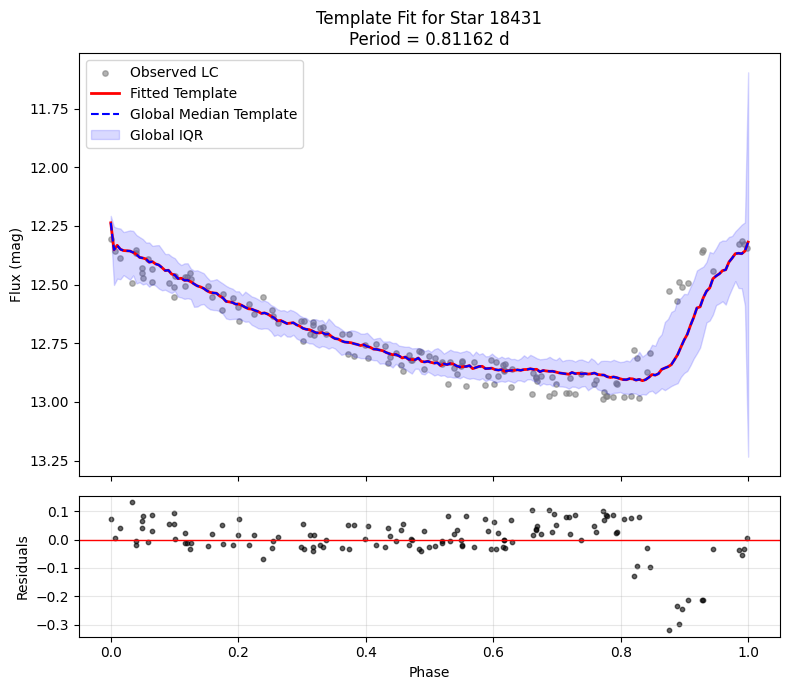

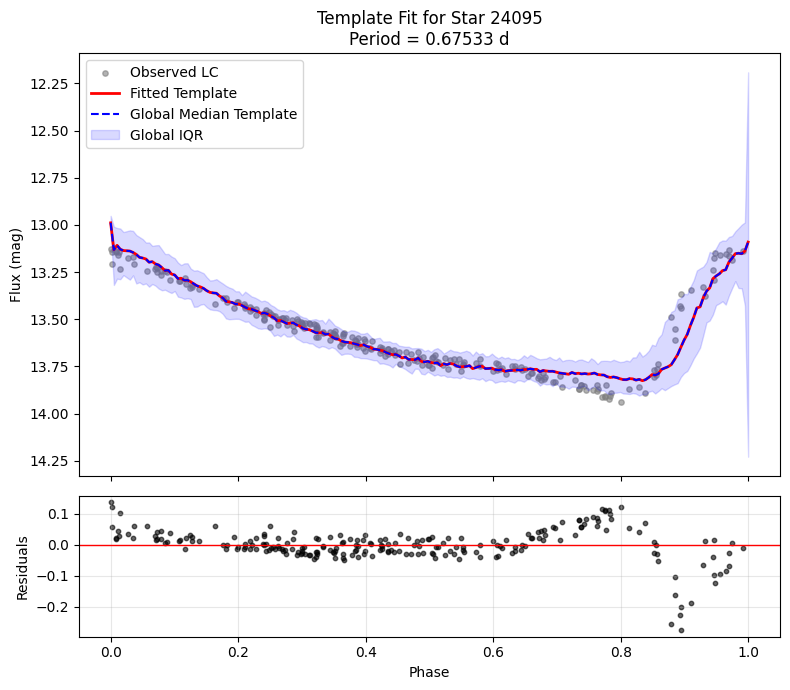

In [33]:
import numpy as np

np.random.seed(42)
random_stars = np.random.choice(fits_df["star_id"].unique(), size=3, replace=False)

for sid_example in random_stars:
    g = lc_df_good[lc_df_good["star_id"] == sid_example].copy().reset_index(drop=True)

    p_ref = fits_df.loc[fits_df["star_id"] == sid_example, "period_refined"].values[0]
    A_fit = fits_df.loc[fits_df["star_id"] == sid_example, "A_fit"].values[0]
    m0_fit = fits_df.loc[fits_df["star_id"] == sid_example, "m0_fit"].values[0]

    phase = ((g["time"] - g["time"].min()) / p_ref) % 1.0
    align_phase = phase[np.argmin(g["flux"].values)]
    phase = (phase - align_phase) % 1.0
    s = np.argsort(phase)
    phase, flux, err = phase[s], g["flux"].values[s], g["flux_err"].values[s]

    T_interp = interp1d(phase_grid, template_mean, kind="cubic", fill_value="extrapolate")
    template_scaled = m0_fit + A_fit * T_interp(phase_grid)
    flux_fit = m0_fit + A_fit * T_interp(phase)
    residuals = flux - flux_fit

    global_median_scaled = m0_fit + A_fit * np.median(templates, axis=0)
    t25 = m0_fit + A_fit * np.percentile(templates, 25, axis=0)
    t75 = m0_fit + A_fit * np.percentile(templates, 75, axis=0)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,7), sharex=True,
                                   gridspec_kw={'height_ratios':[3,1]})

    ax1.scatter(phase, flux, s=15, color='gray', alpha=0.6, label='Observed LC')
    ax1.plot(phase_grid, template_scaled, 'r-', lw=2, label='Fitted Template')
    ax1.plot(phase_grid, global_median_scaled, 'b--', lw=1.5, label='Global Median Template')
    ax1.fill_between(phase_grid, t25, t75, color='blue', alpha=0.15, label='Global IQR')
    ax1.invert_yaxis()
    ax1.set_ylabel("Flux (mag)")
    ax1.set_title(f"Template Fit for Star {sid_example}\nPeriod = {p_ref:.5f} d")
    ax1.legend()
    ax2.scatter(phase, residuals, s=10, color='black', alpha=0.6)
    ax2.axhline(0, color='red', lw=1)
    ax2.set_xlabel("Phase")
    ax2.set_ylabel("Residuals")
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### Application: sparse LSQ lightcurves >120kpc

#### Sparse ab lightcurves

In [42]:
lc_df_bad = pd.read_csv("filtered_lightcurves_sparse_ab.csv")

In [44]:
lc_df_bad = lc_df_bad.copy()
lc_df_bad = lc_df_bad.dropna(subset=["star_id"])   
lc_df_bad["star_id"] = lc_df_bad["star_id"].astype(int)

period_min, period_max = 0.44, 0.89
lc_df_bad = lc_df_bad[(lc_df_bad["period"] >= period_min) & (lc_df_bad["period"] <= period_max)]

print("Unique sparse star IDs:", lc_df_bad["star_id"].nunique())

Unique sparse star IDs: 86


In [46]:
results = []

for sid, g in lc_df_bad.groupby("star_id"):
    t = g["time"].values
    f = g["flux"].values
    fe = g["flux_err"].values
    p = g["period"].iloc[0]

    p_refined = refine_period(t, f, fe, p, phase_grid, template_mean)
    
    A_fit, m0_fit, rss_val = fit_template_single(t, f, fe, p_refined, phase_grid, template_mean)

    results.append({
        "star_id": sid,
        "period_init": p,
        "period_refined": p_refined,
        "A_fit": A_fit,
        "m0_fit": m0_fit,
        "rss": rss_val})

fits_df_bad = pd.DataFrame(results)
print(fits_df_bad.head())


   star_id  period_init  period_refined     A_fit     m0_fit         rss
0      373     0.557835        0.557826  0.918916  20.638248   59.441146
1      591     0.689047        0.689053  0.805068  20.457479  168.226127
2      664     0.497870        0.497861  0.962606  20.952223    8.496003
3      952     0.797683        0.797699  1.204548  20.340354   31.598794
4     1117     0.672582        0.672536  0.392482  20.430543   59.874303


#### Fitting subset of sparse ab-type lightcurves with same 

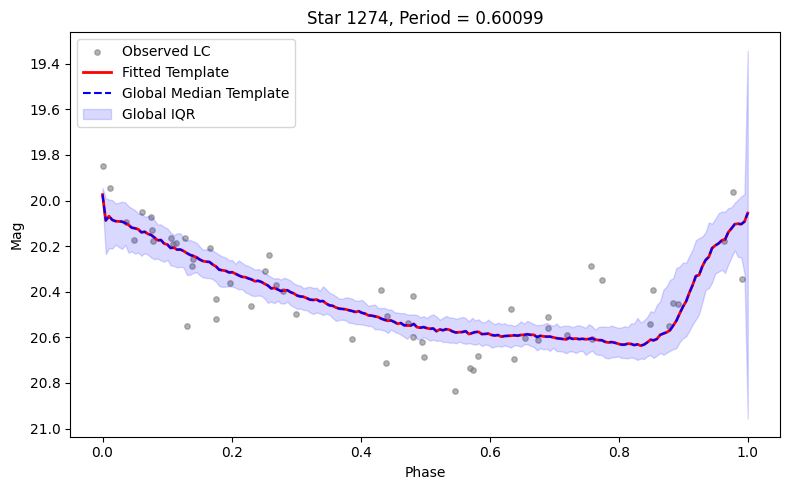

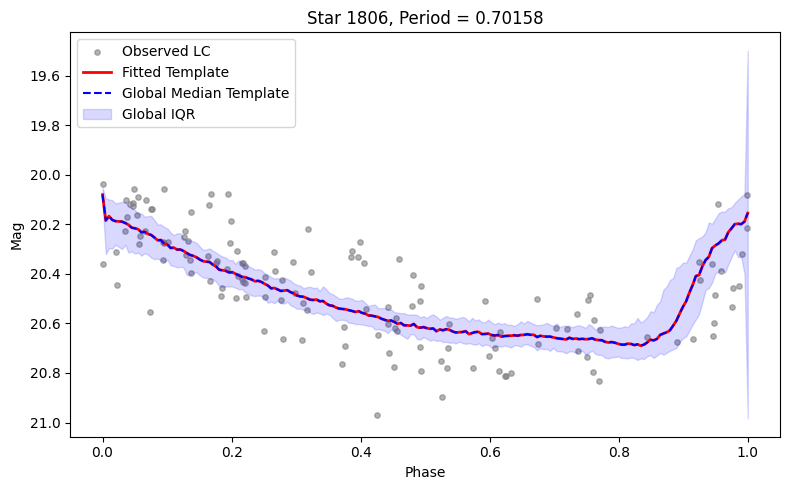

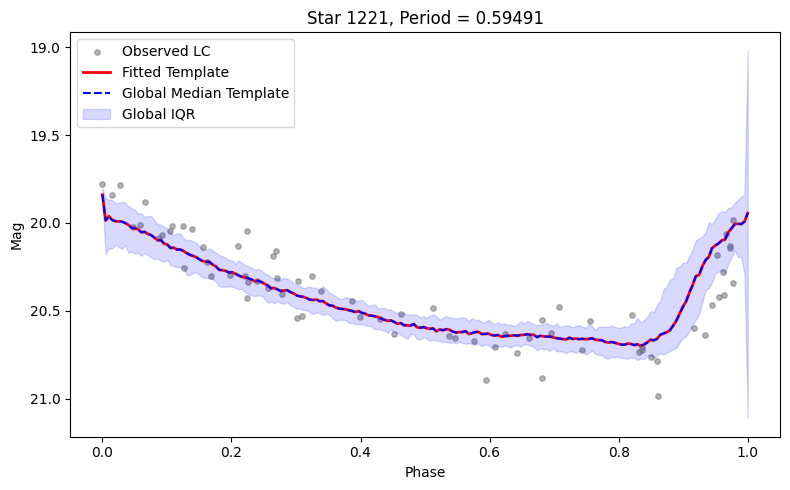

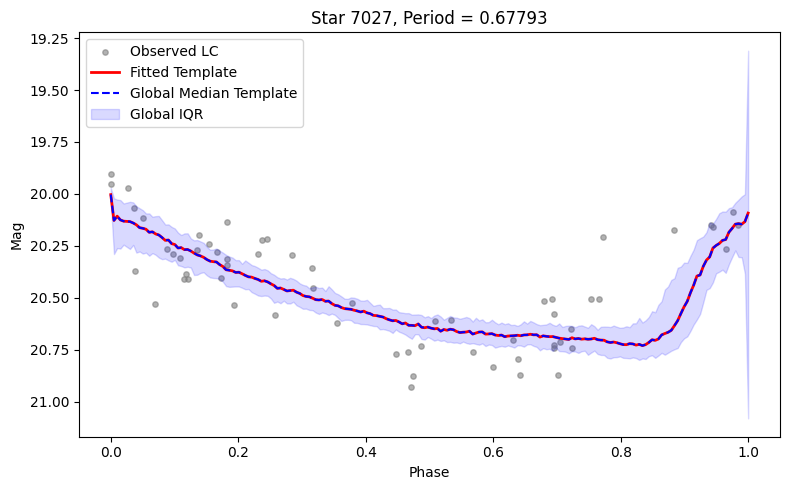

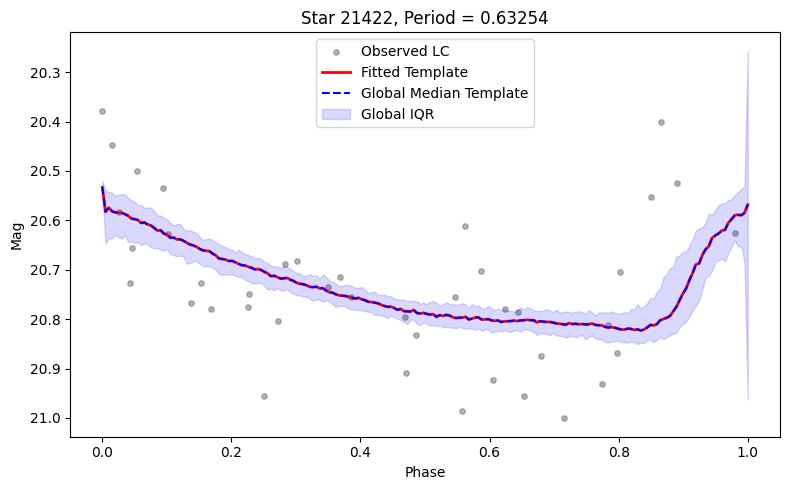

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

lc_df_bad = lc_df_bad.dropna(subset=["star_id"]).copy()
lc_df_bad["star_id"] = lc_df_bad["star_id"].astype(int)

n_stars = 5
unique_ids = lc_df_bad["star_id"].unique()
bad_star_ids = np.random.choice(unique_ids, size=min(n_stars, len(unique_ids)), replace=False)

for sid_example in bad_star_ids:
    g = lc_df_bad[lc_df_bad["star_id"] == sid_example]
    if g.empty or g["flux"].isna().all():
        print(f"Skipping star {sid_example} (no valid flux points)")
        continue

    p_ref = float(g["period"].iloc[0])
    if p_ref == 0 or np.isnan(p_ref):
        print(f"Skipping star {sid_example} (invalid period)")
        continue

    phase = ((g["time"].values - g["time"].min()) / p_ref) % 1.0
    flux  = g["flux"].values
    err   = g["flux_err"].values
    if len(flux) == 0:
        continue

    align_phase = phase[np.argmin(flux)]
    phase_folded = (phase - align_phase) % 1.0
    s = np.argsort(phase_folded)
    phase_folded, flux, err = phase_folded[s], flux[s], err[s]

    T_interp = interp1d(phase_grid, template_mean, kind="cubic", fill_value="extrapolate")
    T_vals = T_interp(phase_folded)

    w = 1.0 / np.where(err > 0, err, np.median(err))**2
    X = np.vstack([np.ones_like(T_vals), T_vals]).T
    coeffs = np.linalg.lstsq(X * np.sqrt(w)[:, None], flux * np.sqrt(w), rcond=None)[0]
    m0_fit, A_fit = coeffs

    template_scaled = m0_fit + A_fit * T_interp(phase_grid)
    global_median_scaled = m0_fit + A_fit * np.median(templates, axis=0)
    t25 = m0_fit + A_fit * np.percentile(templates, 25, axis=0)
    t75 = m0_fit + A_fit * np.percentile(templates, 75, axis=0)

    plt.figure(figsize=(8, 5))
    plt.scatter(phase_folded, flux, s=15, color='gray', alpha=0.6, label='Observed LC')
    plt.plot(phase_grid, template_scaled, 'r-', lw=2, label='Fitted Template')
    plt.plot(phase_grid, global_median_scaled, 'b--', lw=1.5, label='Global Median Template')
    plt.fill_between(phase_grid, t25, t75, color='blue', alpha=0.15, label='Global IQR')
    plt.gca().invert_yaxis()
    plt.xlabel("Phase")
    plt.ylabel("Mag")
    plt.title(f"Star {sid_example}, Period = {p_ref:.5f}")
    plt.legend()
    plt.tight_layout()
    plt.show()